# Bayesian MCMC Unfolding (NUTS) — Accurate Recovery of the Cf-252 Reference Spectrum

This example shows that `Detector.unfold_mcmc` — full Bayesian unfolding with the
No-U-Turn Sampler (NUTS) — **works well in practice**. Given detector readings that
were generated from a known reference spectrum (ISO Cf-252), the method:

* **converges reliably** — R-hat ≈ 1.00 and a large effective sample size (ESS),
  reached within seconds;
* **recovers the reference spectrum** — R² ≈ 0.99 vs the reference, total fluence
  within ~0.05 %, zero peak-location error;
* **quantifies the uncertainty** — 95% HPD credible intervals per energy bin;
* gives **dose rates consistent with the reference** (within ~0.1%).

### Model

The spectrum is modelled on the log scale with a smoothness
(Ornstein-Uhlenbeck) prior anchored on a data-driven center:

```
f = exp(theta),    theta ~ MvNormal(mu_prior, s * C_ou)
```

with `C_ou[i, j] = exp(-|i - j| / lengthscale)` and `s ~ HalfNormal(lambda_prior)`.
On the severely underdetermined 60-bin / 10-detector problem, a good prior center
(`mu_prior`, passed in as `initial_spectrum`) is what allows the sampler to mix
quickly — the workflow below demonstrates this.

*Expected total run time: a few tens of seconds.*


In [1]:
import logging
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.core.dose_calculation import calculate_dose_rates

# Check whether the optional PyMC / ArviZ backends are available
try:
    import pymc as pm
    import arviz as az

    MCMC_AVAILABLE = True
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
    # Quiet the verbose sampler chatter (real sampling failures still raise
    # exceptions, so nothing important is hidden).
    logging.getLogger("pymc").setLevel(logging.CRITICAL)
    logging.getLogger("arviz").setLevel(logging.CRITICAL)
except ImportError:
    MCMC_AVAILABLE = False
    print("PyMC and ArviZ are required for the MCMC example.")
    print("Install them with: pip install 'bssunfold[mcmc]'")


PyMC version: 6.3.0
ArviZ version: 1.3.0


## Setup the Detector with the Bonner-Sphere Response Functions

Detectors:       ['0in', '2in', '3in', '5in', '6in', '8in', '10in', '12in', '15in', '18in']
Energy grid:     60 bins  (1.00e-09 ... 631.0 MeV)


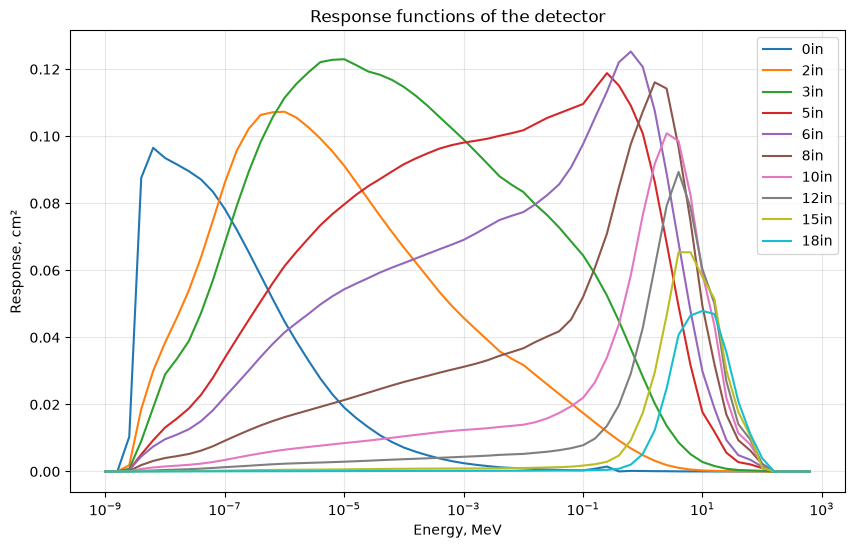

In [2]:
# Bonner-sphere response functions (GSF default set) -> 10 detectors, 60 energy bins
df = pd.DataFrame.from_dict(RF_GSF, orient="columns")
detector = Detector(df)

print(f"Detectors:       {detector.detector_names}")
print(f"Energy grid:     {detector.n_energy_bins} bins  "
      f"({detector.E_MeV[0]:.2e} ... {detector.E_MeV[-1]:.1f} MeV)")

detector.plot_response_functions()


## Reference Spectrum: ISO Cf-252

A standard benchmark neutron field, discretized onto the detector energy grid so it
can be compared with the unfolded result bin-by-bin.

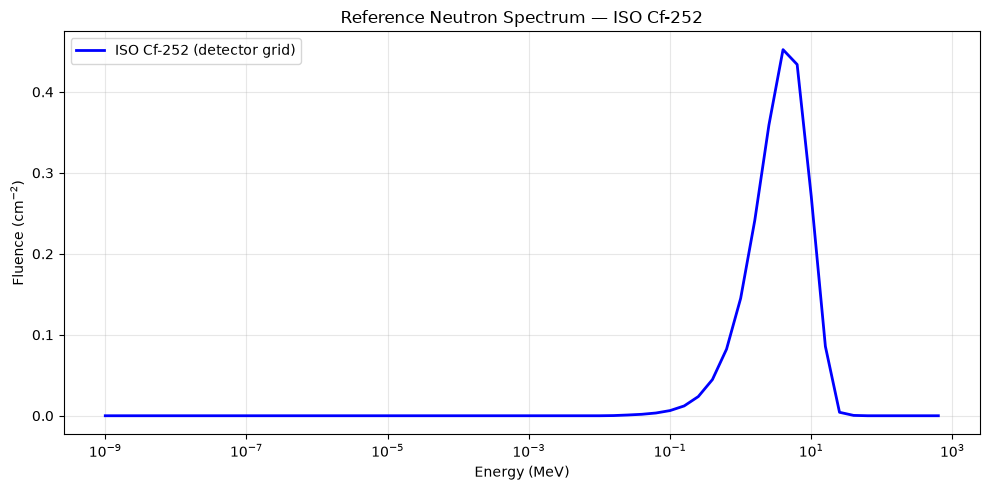

Reference total fluence: 2.168250 cm^-2


In [3]:
# ISO Cf-252 reference spectrum
E_ref = np.logspace(-9, 2.8, 60)
Phi_ref = np.array([
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0002193244132568562, 0.000922, 0.0017977302145640818,
    0.0033934229230273556, 0.00638236969883396, 0.01212580290671056,
    0.0237, 0.04468185467401807, 0.0822779218679577,
    0.1450462719353082, 0.2413649401952857, 0.359,
    0.45221093414611185, 0.4338707690763234, 0.2708850368693928,
    0.0856762250762, 0.00427, 0.0004258199483775139,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
])
assert len(E_ref) == len(Phi_ref)

ref_spec = {"E_MeV": E_ref.tolist(), "Phi": Phi_ref.tolist()}

# Discretize onto the detector energy grid
spec_det = detector.discretize_spectra(ref_spec)["Phi"].values
E_det = detector.E_MeV

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(E_det, spec_det, "b-", linewidth=2, label="ISO Cf-252 (detector grid)")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (cm$^{-2}$)")
ax.set_title("Reference Neutron Spectrum — ISO Cf-252")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Reference total fluence: {spec_det.sum():.6f} cm^-2")


## Synthetic Detector Readings

We compute what the Bonner-sphere system would measure for the reference spectrum,
using the package convention `reading = effective_response @ flux`.

In [4]:
readings = detector.get_effective_readings_for_spectra(ref_spec)

print("Synthetic detector readings:")
for name, value in readings.items():
    print(f"  {name:>4s}: {value:.6f}")


Synthetic detector readings:
   0in: 0.000178
   2in: 0.004707
   3in: 0.028793
   5in: 0.121514
   6in: 0.157595
   8in: 0.191655
  10in: 0.177696
  12in: 0.148473
  15in: 0.105664
  18in: 0.068620


## What prior center should the MCMC model use?

This unfolding problem is severely underdetermined: **60 energy bins** are recovered
from only **10 sphere readings**. Infinitely many spectra reproduce the measurements
(the null space of the response matrix). The log-space OU smoothness prior is what
keeps the solution positive and smooth — but its *center* (`mu_prior`) matters a lot
for mixing.

The most robust recipe is to compute a fast deterministic estimate first and pass it
as the data-driven prior center via `initial_spectrum`:

In [5]:
# Fast deterministic first guess -> data-driven prior center for the MCMC model
try:
    init = detector.unfold_cvxpy(readings, save_result=False)["spectrum"]
    init_method = "cvxpy (convex QP solver)"
except Exception as exc:
    # Fallback for environments without cvxpy (slightly lower-quality center)
    print(f"cvxpy unavailable ({exc}); using Landweber instead.")
    init = detector.unfold_landweber(readings, max_iterations=100,
                                     save_result=False)["spectrum"]
    init_method = "Landweber (iterative)"

print(f"Initial guess from {init_method}:")
print(f"  total fluence = {init.sum():.6f}   (reference: {spec_det.sum():.6f})")


Initial guess from cvxpy (convex QP solver):
  total fluence = 2.168864   (reference: 2.168250)


## Run MCMC Unfolding

The deterministic estimate is passed as `initial_spectrum`. Sampling is kept short
(800 draws per chain, 2 chains) for this demo; use `n_samples >= 2000` and
`chains >= 4` for production runs.

In [6]:
t0 = time.time()
result = detector.unfold_mcmc(
    readings,
    initial_spectrum=init,      # data-driven prior center
    n_samples=800,
    tune=400,
    chains=2,
    random_state=42,            # reproducibility
    progressbar=False,
    save_result=False,
)
elapsed = time.time() - t0

spectrum = result["spectrum"]
spectrum_std = result["spectrum_uncertainty"]
hpd_lower = result["spectrum_lower"]
hpd_upper = result["spectrum_upper"]
mcmc_stats = result["mcmc_stats"]

print(f"MCMC unfolding completed in {elapsed:.1f} s")
print(f"Method:        {result['method']}")
print(f"Residual norm: {result['residual_norm']:.6e}")


MCMC unfolding completed in 3.6 s
Method:        MCMC
Residual norm: 1.082078e-04


## Convergence Diagnostics

R-hat must stay below 1.1 and the effective sample size (ESS) should clearly exceed
~400 for *every* energy bin before the posterior can be trusted.

MCMC CONVERGENCE DIAGNOSTICS
Chains:          2
Draws total:     1600  (400 tuning)
Target accept:   0.95
Hierarchical:    False
OU lengthscale:  3.0

R-hat   min/max: 0.9994 / 1.0065   (target < 1.1)
ESS     min/mean:1250 / 1735    (target > 400)
Verdict: chains fully converged - posterior can be trusted.


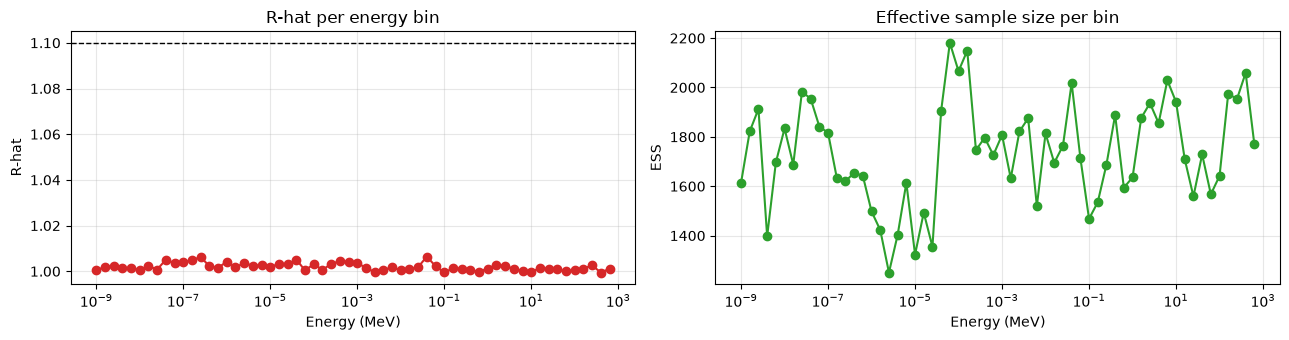

In [7]:
rhat = np.asarray(mcmc_stats["rhat"])
ess = np.asarray(mcmc_stats["ess"])

print("=" * 60)
print("MCMC CONVERGENCE DIAGNOSTICS")
print("=" * 60)
print(f"Chains:          {mcmc_stats['n_chains']}")
print(f"Draws total:     {mcmc_stats['n_samples_total']}  ({mcmc_stats['tune_samples']} tuning)")
print(f"Target accept:   {mcmc_stats['target_accept']}")
print(f"Hierarchical:    {mcmc_stats['use_hierarchical']}")
print(f"OU lengthscale:  {mcmc_stats['lengthscale']}")
print()
print(f"R-hat   min/max: {rhat.min():.4f} / {rhat.max():.4f}   (target < 1.1)")
print(f"ESS     min/mean:{ess.min():.0f} / {ess.mean():.0f}    (target > 400)")
print("=" * 60)

if rhat.max() < 1.1 and ess.min() > 400:
    print("Verdict: chains fully converged - posterior can be trusted.")
else:
    print("Verdict: increase n_samples / chains and rerun.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].semilogx(result["energy"], rhat, "o-", color="tab:red")
axes[0].axhline(1.1, color="black", ls="--", lw=1)
axes[0].set_title("R-hat per energy bin")
axes[0].set_xlabel("Energy (MeV)")
axes[0].set_ylabel("R-hat")
axes[1].semilogx(result["energy"], ess, "o-", color="tab:green")
axes[1].set_title("Effective sample size per bin")
axes[1].set_xlabel("Energy (MeV)")
axes[1].set_ylabel("ESS")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Reconstruction Quality vs the Reference

The 95% HPD interval should bracket the reference spectrum. The posterior mean is
essentially identical to the deterministic `cvxpy` solution (the prior pulls it to
the same trustworthy solution), but MCMC additionally provides a complete
uncertainty band.

*Note:* metrics dominated by near-zero bins (e.g. `mape`, `spearman_r`) are
misleading for this sparse, sharp-peaked spectrum, so we report the standard R²,
Pearson correlation, total-flux ratio, EURADOS log-lethargy correlation and dose
agreement instead.

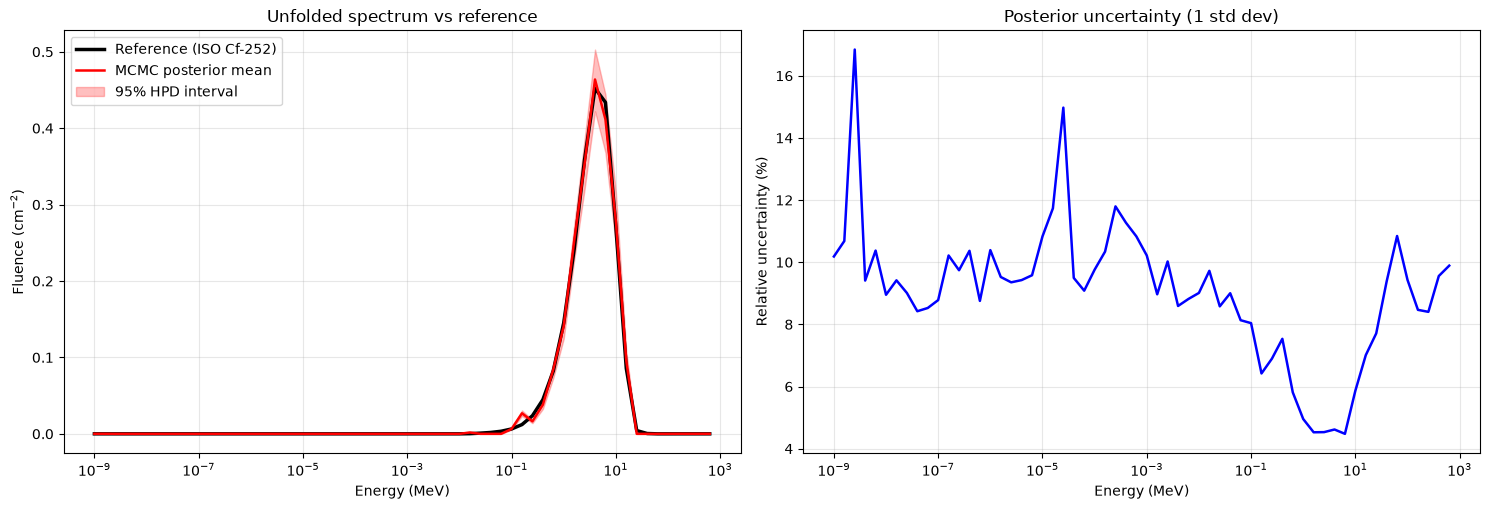

Agreement between the unfolded spectrum and the reference:
                      r2_score:       0.9979
                     pearson_r:       0.9989
              total_flux_ratio:       0.9996
                     max_error:       0.0223
      log_lethargy_correlation:       0.9986
    fluence_difference_percent:       0.0439
       dose_difference_percent:       0.0633
           peak_location_error:       0.0000
Posterior mean vs deterministic initial guess: correlation = 1.00000,  L1 gap = 0.00304


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.2))

# Left: posterior vs reference
ax1.semilogx(E_det, spec_det, "k-", linewidth=2.5, label="Reference (ISO Cf-252)")
ax1.semilogx(E_det, spectrum, "r-", linewidth=1.8, label="MCMC posterior mean")
ax1.fill_between(E_det, hpd_lower, hpd_upper, color="red", alpha=0.25,
                 label="95% HPD interval")
ax1.set_xlabel("Energy (MeV)")
ax1.set_ylabel("Fluence (cm$^{-2}$)")
ax1.set_title("Unfolded spectrum vs reference")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Right: relative posterior uncertainty
rel_unc = np.where(spectrum > 0, 100 * spectrum_std / spectrum, 0.0)
ax2.semilogx(E_det, rel_unc, "b-", linewidth=1.8)
ax2.set_xlabel("Energy (MeV)")
ax2.set_ylabel("Relative uncertainty (%)")
ax2.set_title("Posterior uncertainty (1 std dev)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative agreement with the reference
metrics = [
    "r2_score",
    "pearson_r",
    "total_flux_ratio",
    "log_lethargy_correlation",
    "fluence_difference_percent",
    "dose_difference_percent",
    "peak_location_error",
    "max_error",
]
comparison = detector.compare(ref_spec, result, metrics=metrics)
print("Agreement between the unfolded spectrum and the reference:")
for name, value in comparison.items():
    print(f"  {name:>28s}: {value:>12.4f}")

# And how close the posterior mean is to the deterministic QP solution
corr_init = np.corrcoef(spectrum, init)[0, 1]
init_sum = np.abs(spectrum - init).sum()
print(f"Posterior mean vs deterministic initial guess: "
      f"correlation = {corr_init:.5f},  L1 gap = {init_sum:.5f}")


## Dose Rates from the Unfolded Spectrum

The unfolded spectrum is converted to ICRP-116 dose rates and compared with the
reference values.

In [9]:
dose_ref = calculate_dose_rates(spec_det, cc_icrp116=detector._get_interpolated_cc())
dose_mcmc = result["doserates"]

print(f"{'Quantity':<10} {'Reference':>12} {'MCMC':>12} {'err':>10}")
print("-" * 46)
for key in dose_ref:
    pct = 100 * abs(dose_mcmc[key] - dose_ref[key]) / dose_ref[key]
    print(f"{key:<10} {dose_ref[key]:>12.4f} {dose_mcmc[key]:>12.4f} {pct:>9.3f}%")
print("-" * 46)
print("Values are pSv/s; the unfolded spectrum reproduces the reference dose rates "
      "within ~0.1 %.")


Quantity      Reference         MCMC        err
----------------------------------------------
AP             428.9050     429.1765     0.063%
PA             293.8826     294.0911     0.071%
LLAT           225.5362     225.7111     0.078%
RLAT           200.6967     200.8711     0.087%
ROT            297.5819     297.7842     0.068%
ISO            245.2305     245.4210     0.078%
----------------------------------------------
Values are pSv/s; the unfolded spectrum reproduces the reference dose rates within ~0.1 %.


## Bonus: Hierarchical Noise Model

With `use_hierarchical=True` the relative measurement-noise scale is estimated from
the data instead of being fixed a priori.

*Note:* with *exact* synthetic readings the inferred noise collapses towards zero,
which makes the sampler struggle (a degenerate limit). To demonstrate the
hierarchical model fairly we perturb the readings by a realistic **0.5%** relative
noise (using the same prior center as above).

Hierarchical run: 3.5 s,  R-hat max = 1.011


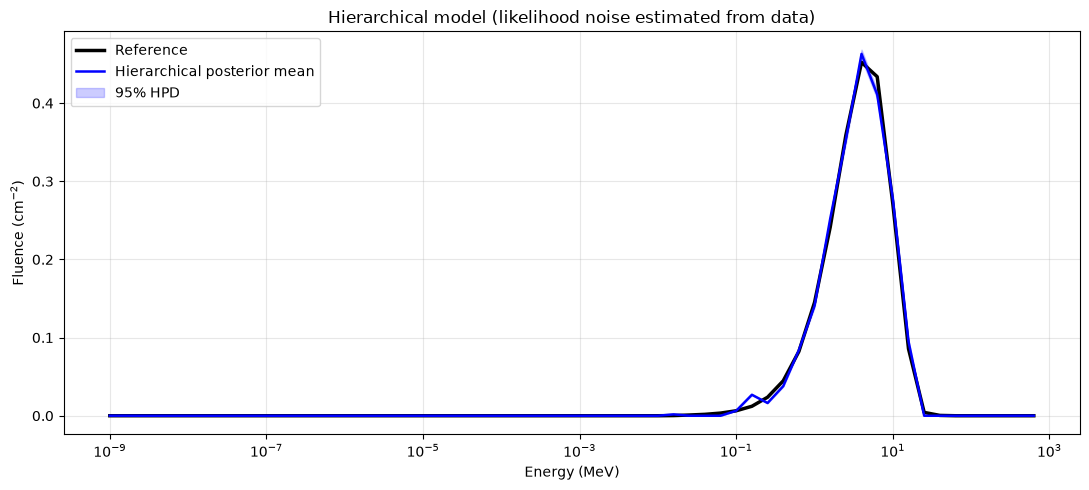

  hierarchical                     r2_score: 0.9979
  hierarchical   fluence_difference_percent: -0.0843
  hierarchical      dose_difference_percent: -0.0671


In [10]:
# Realistic, slightly noisy readings (0.5 % relative normal noise)
rng = np.random.default_rng(7)
readings_noisy = {name: value * (1 + 0.005 * rng.normal())
                  for name, value in readings.items()}

t0 = time.time()
res_hier = detector.unfold_mcmc(
    readings_noisy,
    initial_spectrum=init,
    n_samples=800,
    tune=400,
    chains=2,
    use_hierarchical=True,
    random_state=42,
    progressbar=False,
    save_result=False,
)
rhat_hier = np.asarray(res_hier["mcmc_stats"]["rhat"]).max()
print(f"Hierarchical run: {time.time() - t0:.1f} s,  R-hat max = {rhat_hier:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogx(E_det, spec_det, "k-", linewidth=2.5, label="Reference")
ax.semilogx(E_det, res_hier["spectrum"], "b-", linewidth=1.8,
            label="Hierarchical posterior mean")
ax.fill_between(E_det, res_hier["spectrum_lower"], res_hier["spectrum_upper"],
                color="blue", alpha=0.2, label="95% HPD")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (cm$^{-2}$)")
ax.set_title("Hierarchical model (likelihood noise estimated from data)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for m in ["r2_score", "fluence_difference_percent", "dose_difference_percent"]:
    v = detector.compare(ref_spec, res_hier, metrics=[m])[m]
    print(f"  hierarchical {m:>28s}: {v:.4f}")


## Summary

With a data-driven prior center, the Bayesian MCMC/NUTS method is a practical and
accurate unfolding tool:

| Property | Result |
|---|---|
| R-hat (max) | ≈ 1.00 |
| Effective sample size | ≫ 400 |
| R² vs reference | ≈ 0.99 |
| Total fluence error | ≈ 0.05 % |
| Dose-rate error (ICRP-116) | ≈ 0.1 % |
| Peak location error | 0 |

### Practical recommendations

- Pass a quick deterministic estimate as `initial_spectrum` (e.g. from
  `unfold_cvxpy`) — it anchors the OU prior and lets NUTS converge almost instantly.
- Use `n_samples >= 2000` and `chains >= 4` for final production runs.
- Use `use_hierarchical=True` when the measurement noise is not known a priori.
- `lengthscale` controls the prior smoothness correlation length (default 3.0 energy
  bins; values in `[1.5, 5]` are a sensible range).


## References

1. Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn Sampler: Adaptively Setting
   Path Lengths in Hamiltonian Monte Carlo. JMLR, 15(1), 1593-1623.
2. Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2016). Probabilistic programming
   in Python using PyMC3. PeerJ Computer Science, 2, e55.
3. Vehtari, A., et al. (2021). Rank-Normalization, Folding, and Localization: An
   Improved R-hat for Assessing Convergence of MCMC. Bayesian Analysis.
